<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# initial-data-exploratory-data-analysis

This notebook is the first in a series exploring the capstone project’s Bayesian Optimisation (BBO) challenge. It focuses on exploratory data analysis (EDA) of the initial dataset and follows **Mini-Lesson 12.8: Data and Descriptions of Functions for the Bayesian Optimisation Competition**.

The notebook was developed during **Module 12: Bayesian Optimisation**.

### Key Findings / Insights

* The dataset contains **8 benchmark functions (F1–F8)** with different levels of complexity.
* The functions range from **2 to 8 input dimensions** and contain **10–40 observations**.
* All variables are numerical, consisting of multiple `Input_*` variables and an `Output` variable.
* Initial data inspection shows **no missing values** in the dataset examined.
* "Summary" plots are compared for 8 Functions.
   * **Feature Correlations** & Target Summary Across All Functions (F1 - F8)
   * Output Values **Distribution** Across Functions (Boxplot on symlog scale)
   * Surrogate Model Performance Across All 8 Functions (**Gaussian Process Regression**)
   * **Optimal Surrogate** Models: CV Predicted vs. Actual Output (Functions F1 to F8)
* **Correlation analysis and heatmaps** were used to investigate relationships between inputs and the output.
* **Histograms and boxplots** were used to assess variable distributions and identify potential outliers.
* **Pair plots** were used to explore relationships between input variables and identify potential dependencies.
* The increasing dimensionality across F1–F8 provides a useful way to evaluate how Bayesian Optimisation performs as **problem complexity increases**.
* Correlation analysis provides useful initial insights, but **nonlinear relationships may not be captured by correlation alone**.
* The EDA provides a baseline understanding of the benchmark functions before applying **Bayesian Optimisation**.
* Performance should be evaluated **separately for each benchmark function**, particularly when comparing low- and high-dimensional problems.
* Potential outliers and unusual observations should be investigated before interpreting the optimisation results.

## Summary

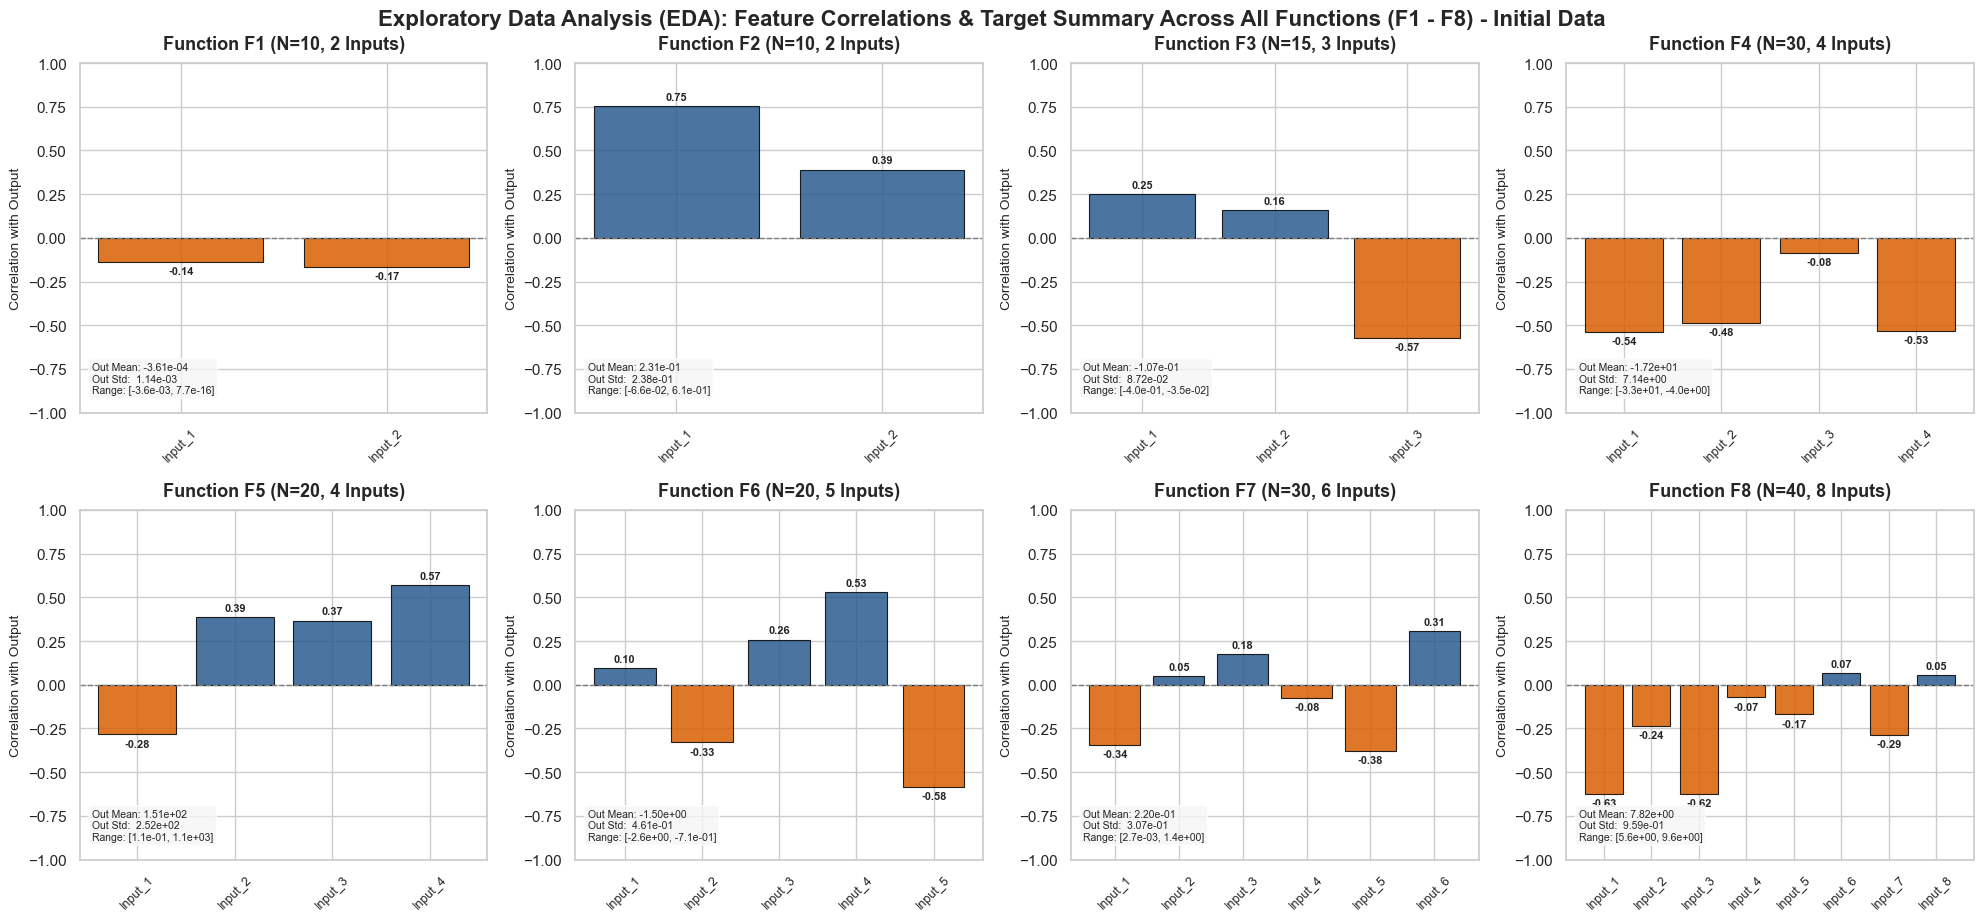

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

xls = pd.ExcelFile('initial_data/CapstoneFunction_from_Numpy.xlsx')
sheets = xls.sheet_names

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sheet in enumerate(sheets):
    df = pd.read_excel(xls, sheet_name=sheet)
    ax = axes[idx]
    
    # Calculate correlation with Output
    corr = df.corr()['Output'].drop('Output')
    
    # Bar plot of feature correlations
    colors = ['#2b5c8f' if c >= 0 else '#d95f02' for c in corr.values]
    bars = ax.bar(corr.index, corr.values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
    
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    ax.set_ylim(-1.0, 1.0)
    ax.set_title(f"Function {sheet} (N={len(df)}, {len(corr)} Inputs)", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel("Correlation with Output", fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    
    # Add values on top/bottom of bars
    for bar in bars:
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        ax.annotate(f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3 if height >= 0 else -3),
                    textcoords="offset points",
                    ha='center', va=va, fontsize=8, fontweight='bold')
        
    # Text box with key stats
    out_mean = df['Output'].mean()
    out_std = df['Output'].std()
    out_min = df['Output'].min()
    out_max = df['Output'].max()
    
    stats_text = f"Out Mean: {out_mean:.2e}\nOut Std:  {out_std:.2e}\nRange: [{out_min:.1e}, {out_max:.1e}]"
    ax.text(0.03, 0.05, stats_text, transform=ax.transAxes, fontsize=7.5,
            verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.3', facecolor='whitesmoke', alpha=0.8))

plt.suptitle("Exploratory Data Analysis (EDA): Feature Correlations & Target Summary Across All Functions (F1 - F8) - Initial Data",
             fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# plt.savefig("eda_all_functions.png", dpi=300)
# plt.close()
# print("Figure created successfully.")

C:\Users\mayzu\AppData\Local\Temp\ipykernel_34904\2629256358.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax11.set_xticklabels(sheets, fontsize=9, fontweight='bold')


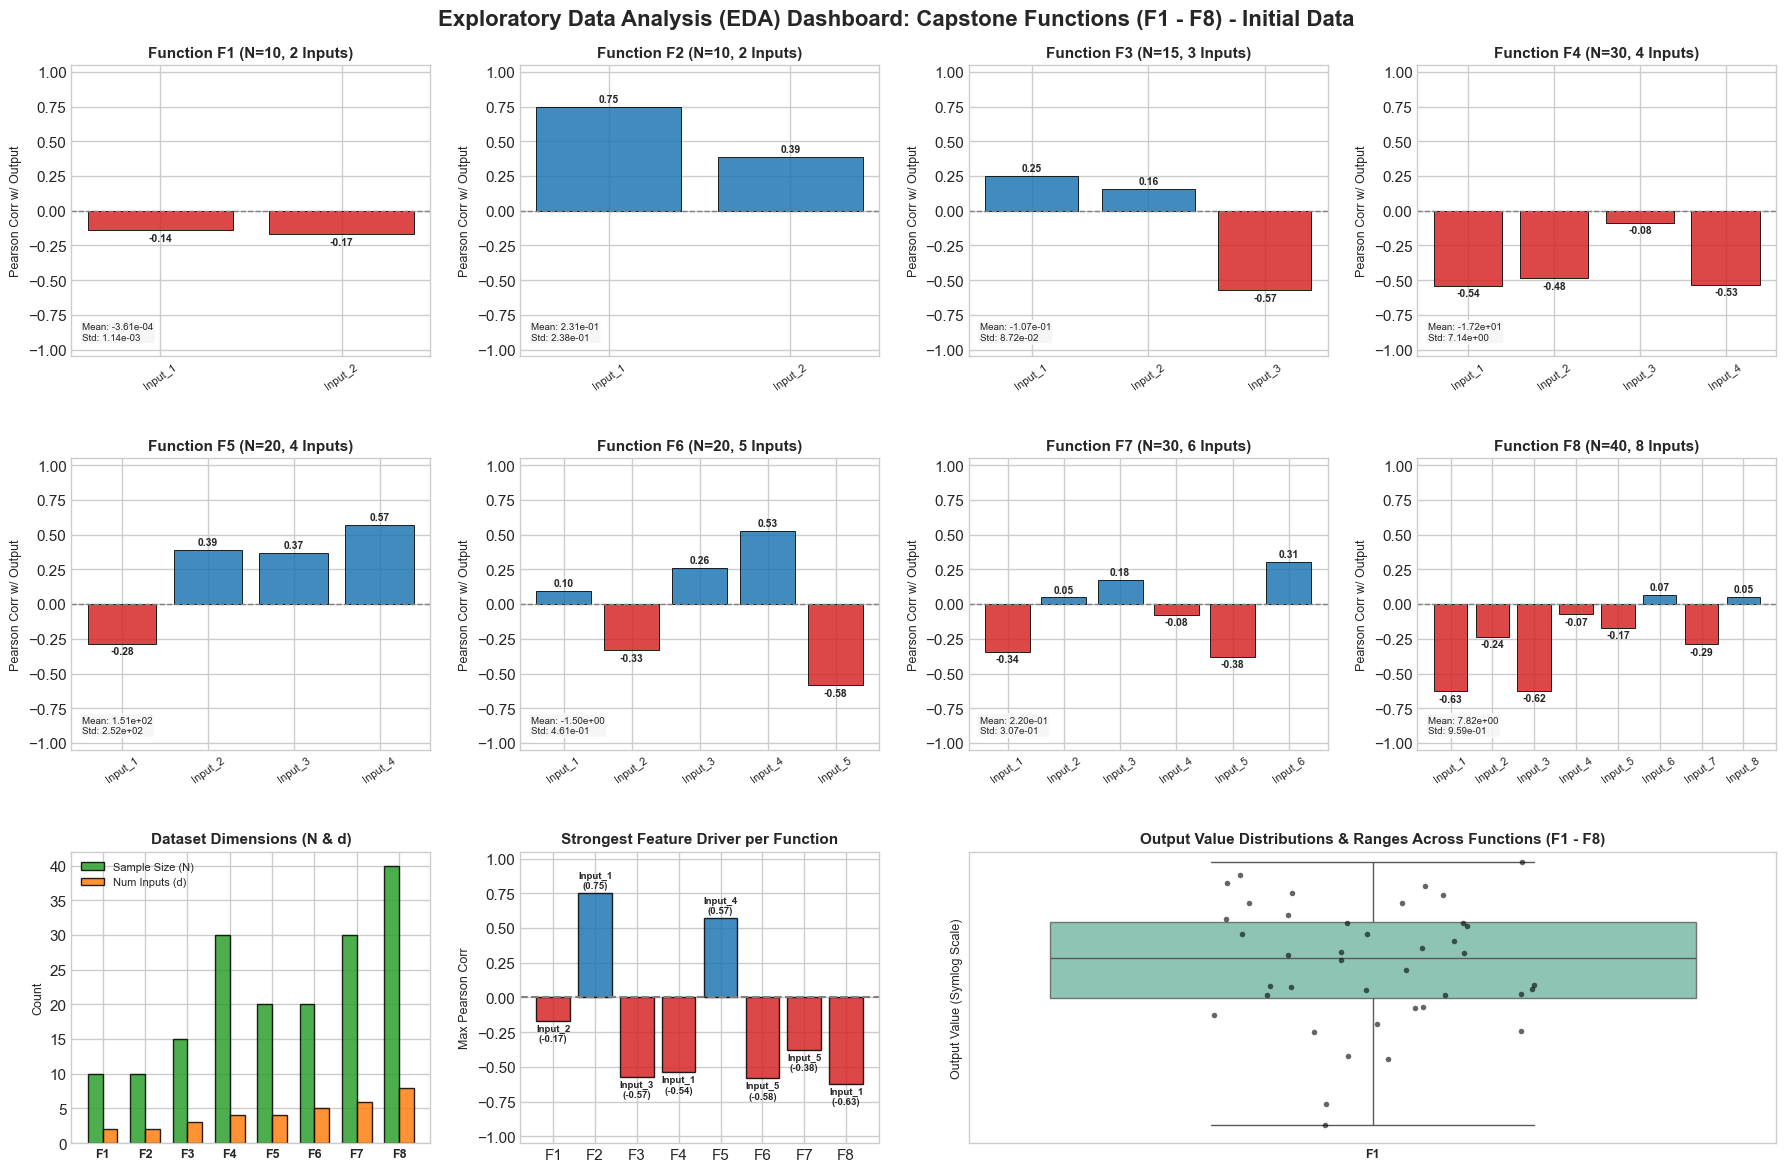

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sheets = xls.sheet_names

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(22, 14))

# Define GridSpec: 3 rows, 4 columns
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.25)

# Subplots for F1 - F8
for idx, sheet in enumerate(sheets):
    row = idx // 4
    col = idx % 4
    ax = fig.add_subplot(gs[row, col])
    
    df = pd.read_excel(xls, sheet_name=sheet)
    corr = df.corr()['Output'].drop('Output')
    
    # Color bars by sign
    colors = ['#1f77b4' if c >= 0 else '#d62728' for c in corr.values]
    bars = ax.bar(corr.index, corr.values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.7)
    
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(f"Function {sheet} (N={len(df)}, {len(corr)} Inputs)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Pearson Corr w/ Output", fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    
    for bar in bars:
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        ax.annotate(f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 2 if height >= 0 else -2),
                    textcoords="offset points",
                    ha='center', va=va, fontsize=7.5, fontweight='bold')
        
    stats_text = f"Mean: {df['Output'].mean():.2e}\nStd: {df['Output'].std():.2e}"
    ax.text(0.03, 0.05, stats_text, transform=ax.transAxes, fontsize=7,
            verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.2', facecolor='whitesmoke', alpha=0.85))

# Bottom row: Summary Analytics across functions
# Panel 9: Sample Size (N) vs Dimension (d)
ax9 = fig.add_subplot(gs[2, 0])
n_list = [len(pd.read_excel(xls, s)) for s in sheets]
d_list = [len(pd.read_excel(xls, s).columns) - 1 for s in sheets]
x = np.arange(len(sheets))
width = 0.35

ax9.bar(x - width/2, n_list, width, label='Sample Size (N)', color='#2ca02c', alpha=0.85, edgecolor='black')
ax9.bar(x + width/2, d_list, width, label='Num Inputs (d)', color='#ff7f0e', alpha=0.85, edgecolor='black')
ax9.set_xticks(x)
ax9.set_xticklabels(sheets, fontsize=9, fontweight='bold')
ax9.set_ylabel("Count", fontsize=9)
ax9.set_title("Dataset Dimensions (N & d)", fontsize=11, fontweight='bold')
ax9.legend(fontsize=8, loc='upper left')

# Panel 10: Strongest Absolute Feature Correlation per Function
ax10 = fig.add_subplot(gs[2, 1])
max_corrs = []
max_feats = []
for s in sheets:
    df = pd.read_excel(xls, s)
    corr = df.corr()['Output'].drop('Output')
    abs_corr = corr.abs()
    top_f = abs_corr.idxmax()
    max_corrs.append(corr[top_f])
    max_feats.append(f"{top_f}")

colors_max = ['#1f77b4' if c >= 0 else '#d62728' for c in max_corrs]
bars_max = ax10.bar(sheets, max_corrs, color=colors_max, alpha=0.85, edgecolor='black')
ax10.axhline(0, color='gray', linestyle='--')
ax10.set_ylim(-1.05, 1.05)
ax10.set_ylabel("Max Pearson Corr", fontsize=9)
ax10.set_title("Strongest Feature Driver per Function", fontsize=11, fontweight='bold')
for idx, bar in enumerate(bars_max):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    ax10.annotate(f"{max_feats[idx]}\n({height:.2f})",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 2 if height >= 0 else -2),
                 textcoords="offset points",
                 ha='center', va=va, fontsize=7, fontweight='bold')

# Panel 11: Output Values Distribution Across Functions (Boxplot on symlog scale)
ax11 = fig.add_subplot(gs[2, 2:])
outputs_data = [pd.read_excel(xls, s)['Output'] for s in sheets]
sns.boxplot(data=outputs_data, ax=ax11, palette="Set2", boxprops=dict(alpha=0.8))
sns.stripplot(data=outputs_data, ax=ax11, color='black', alpha=0.6, jitter=0.2, size=4)
ax11.set_xticklabels(sheets, fontsize=9, fontweight='bold')
ax11.set_yscale('symlog', linthresh=1e-3)
ax11.set_ylabel("Output Value (Symlog Scale)", fontsize=9)
ax11.set_title("Output Value Distributions & Ranges Across Functions (F1 - F8)", fontsize=11, fontweight='bold')

# Overall Figure Title
fig.suptitle("Exploratory Data Analysis (EDA) Dashboard: Capstone Functions (F1 - F8) - Initial Data",
             fontsize=16, fontweight='bold', y=0.92)

plt.show()
# plt.savefig("eda_all_functions_dashboard.png", dpi=300, bbox_inches='tight')
# plt.close()
# print("Dashboard image created.")

In [3]:
# Verify all statistical values directly to be 100% accurate in text summary
for s in sheets:
    df = pd.read_excel(xls, s)
    corr = df.corr()['Output'].drop('Output')
    print(f"Sheet {s}: N={len(df)}, Inputs={len(corr)}")
    print(f"  Output Mean: {df['Output'].mean():.4f}, Std: {df['Output'].std():.4f}, Min: {df['Output'].min():.4f}, Max: {df['Output'].max():.4f}")
    top_pos = corr.idxmax()
    top_neg = corr.idxmin()
    print(f"  Top +Corr: {top_pos} ({corr[top_pos]:.3f})")
    print(f"  Top -Corr: {top_neg} ({top_neg} ({corr[top_neg]:.3f}))")

Sheet F1: N=10, Inputs=2
  Output Mean: -0.0004, Std: 0.0011, Min: -0.0036, Max: 0.0000
  Top +Corr: Input_1 (-0.137)
  Top -Corr: Input_2 (Input_2 (-0.169))
Sheet F2: N=10, Inputs=2
  Output Mean: 0.2307, Std: 0.2376, Min: -0.0656, Max: 0.6112
  Top +Corr: Input_1 (0.752)
  Top -Corr: Input_2 (Input_2 (0.390))
Sheet F3: N=15, Inputs=3
  Output Mean: -0.1072, Std: 0.0872, Min: -0.3989, Max: -0.0348
  Top +Corr: Input_1 (0.251)
  Top -Corr: Input_3 (Input_3 (-0.574))
Sheet F4: N=30, Inputs=4
  Output Mean: -17.2386, Std: 7.1380, Min: -32.6257, Max: -4.0255
  Top +Corr: Input_3 (-0.085)
  Top -Corr: Input_1 (Input_1 (-0.540))
Sheet F5: N=20, Inputs=4
  Output Mean: 151.2719, Std: 251.9556, Min: 0.1129, Max: 1088.8596
  Top +Corr: Input_4 (0.570)
  Top -Corr: Input_1 (Input_1 (-0.284))
Sheet F6: N=20, Inputs=5
  Output Mean: -1.4954, Std: 0.4607, Min: -2.5712, Max: -0.7143
  Top +Corr: Input_4 (0.528)
  Top -Corr: Input_5 (Input_5 (-0.584))
Sheet F7: N=30, Inputs=6
  Output Mean: 0.2196, 

Function  Dimension (d)  Samples (N)  Train R2     CV R2   Train RMSE    CV RMSE
      F1              2           10  0.036172 -0.324589 1.062073e-03   0.001245
      F2              2           10  0.998068  0.457534 9.904992e-03   0.165986
      F3              3           15  1.000000 -1.206145 1.717905e-06   0.125084
      F4              4           30  0.906638  0.558361 2.144357e+00   4.663870
      F5              4           20  0.989743  0.359650 2.487140e+01 196.514442
      F6              5           20  0.935712  0.528467 1.138440e-01   0.308320
      F7              6           30  1.000000 -0.341945 5.864237e-08   0.349994
      F8              8           40  1.000000  0.995634 1.325460e-07   0.062565


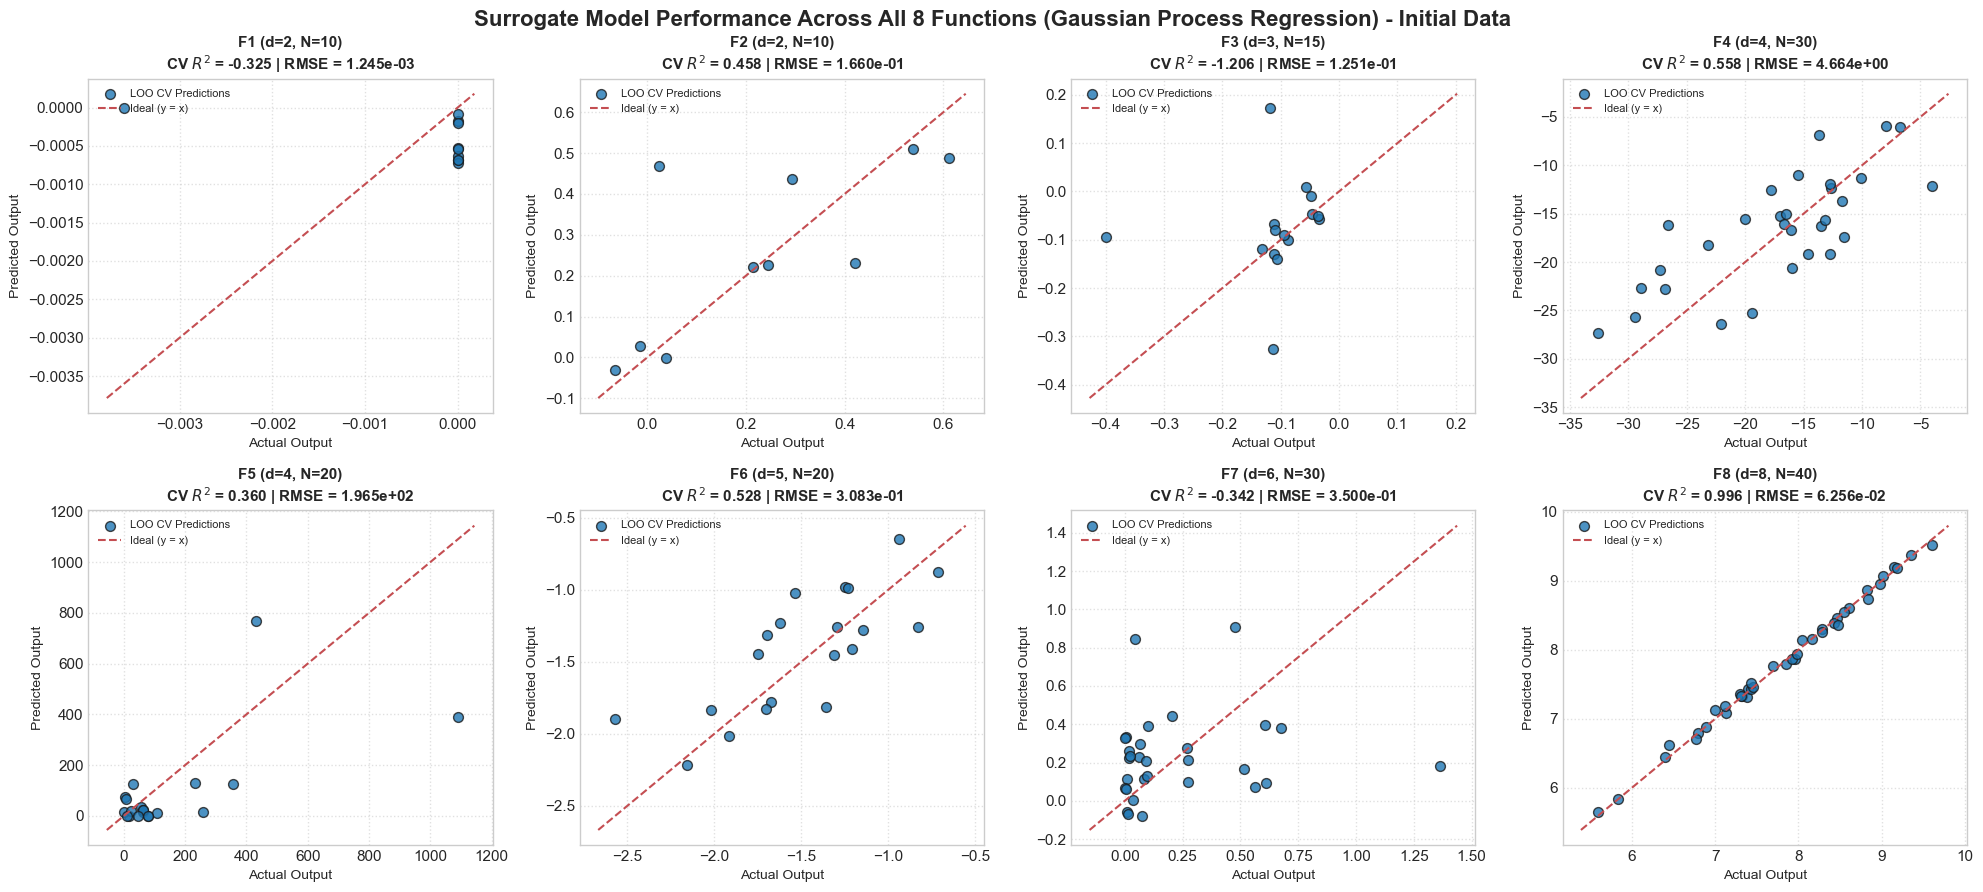

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

sheets = xls.sheet_names

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

metrics_list = []

for idx, s in enumerate(sheets):
    df = pd.read_excel(xls, sheet_name=s)
    X = df.drop(columns=['Output']).values
    y = df['Output'].values
    n_samples, n_features = X.shape
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Gaussian Process Surrogate Model
    kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
    
    # Cross-validation predictions (Leave-One-Out)
    loo = LeaveOneOut()
    y_pred_cv = cross_val_predict(gpr, X_scaled, y, cv=loo)
    
    # Full fit
    gpr.fit(X_scaled, y)
    y_pred_train = gpr.predict(X_scaled)
    
    r2_cv = r2_score(y, y_pred_cv)
    rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))
    r2_train = r2_score(y, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))
    
    metrics_list.append({
        'Function': s,
        'Dimension (d)': n_features,
        'Samples (N)': n_samples,
        'Train R2': r2_train,
        'CV R2': r2_cv,
        'Train RMSE': rmse_train,
        'CV RMSE': rmse_cv
    })
    
    ax = axes[idx]
    # Scatter plot: Actual vs Predicted (CV)
    ax.scatter(y, y_pred_cv, color='#1f77b4', edgecolors='k', alpha=0.8, label='LOO CV Predictions', s=50)
    
    # Perfect prediction line y = x
    min_val = min(min(y), min(y_pred_cv))
    max_val = max(max(y), max(y_pred_cv))
    padding = (max_val - min_val) * 0.05
    line_range = np.linspace(min_val - padding, max_val + padding, 100)
    ax.plot(line_range, line_range, 'r--', label='Ideal (y = x)', linewidth=1.5)
    
    ax.set_title(f"{s} (d={n_features}, N={n_samples})\nCV $R^2$ = {r2_cv:.3f} | RMSE = {rmse_cv:.3e}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Output', fontsize=10)
    ax.set_ylabel('Predicted Output', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Surrogate Model Performance Across All 8 Functions (Gaussian Process Regression) - Initial Data', fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show 
# plt.savefig('surrogate_models_all_functions.png', dpi=300)
# plt.close()

metrics_df = pd.DataFrame(metrics_list)
print(metrics_df.to_string(index=False))

In [6]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

models = {
    'Gaussian Process': GaussianProcessRegressor(kernel=C(1.0)*RBF(np.ones(2))+WhiteKernel(1e-5), n_restarts_optimizer=5, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'SVR (RBF)': SVR(C=1.0, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Poly Ridge (deg 2)': Pipeline([('poly', PolynomialFeatures(degree=2)), ('ridge', Ridge(alpha=1.0))])
}

best_models = {}
comparison_table = []

for s in sheets:
    df = pd.read_excel(xls, sheet_name=s)
    X = df.drop(columns=['Output']).values
    y = df['Output'].values
    n_samples, n_features = X.shape
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    loo = LeaveOneOut()
    
    best_r2 = -float('inf')
    best_name = None
    best_y_pred = None
    
    row_info = {'Function': s, 'd': n_features, 'N': n_samples}
    
    for name, model in models.items():
        try:
            # For GP we need dynamic dimension kernel length_scale
            if name == 'Gaussian Process':
                k = C(1.0, (1e-2, 1e2)) * RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1))
                m = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=5, random_state=42)
            else:
                m = model
                
            y_pred = cross_val_predict(m, X_scaled, y, cv=loo)
            r2 = r2_score(y, y_pred)
            row_info[name] = r2
            
            if r2 > best_r2:
                best_r2 = r2
                best_name = name
                best_y_pred = y_pred
        except Exception as e:
            row_info[name] = np.nan
            
    best_models[s] = {
        'best_model_name': best_name,
        'best_r2': best_r2,
        'y_actual': y,
        'y_pred': best_y_pred,
        'd': n_features,
        'N': n_samples
    }
    comparison_table.append(row_info)

comp_df = pd.DataFrame(comparison_table)
print(comp_df.to_string(index=False))

Function  d  N  Gaussian Process     Ridge  SVR (RBF)  Random Forest  Extra Trees  Poly Ridge (deg 2)
      F1  2 10         -0.324589 -0.335110  -2.611111      -0.692444    -0.621444           -0.596206
      F2  2 10          0.457534  0.111806  -0.385906       0.152641     0.218740           -0.243957
      F3  3 15         -1.206145 -0.524911  -0.836509      -0.393046    -0.239121           -0.234542
      F4  4 30          0.558361  0.413862   0.201028       0.576953     0.628746            0.975512
      F5  4 20          0.359650  0.275597  -0.125252       0.282314     0.428715            0.453908
      F6  5 20          0.528467  0.198806   0.505342       0.306529     0.420789            0.383118
      F7  6 30         -0.341945 -0.059558   0.097451      -0.109628    -0.110065           -0.798823
      F8  8 40          0.995634  0.821060   0.704993       0.715012     0.770380            0.893607


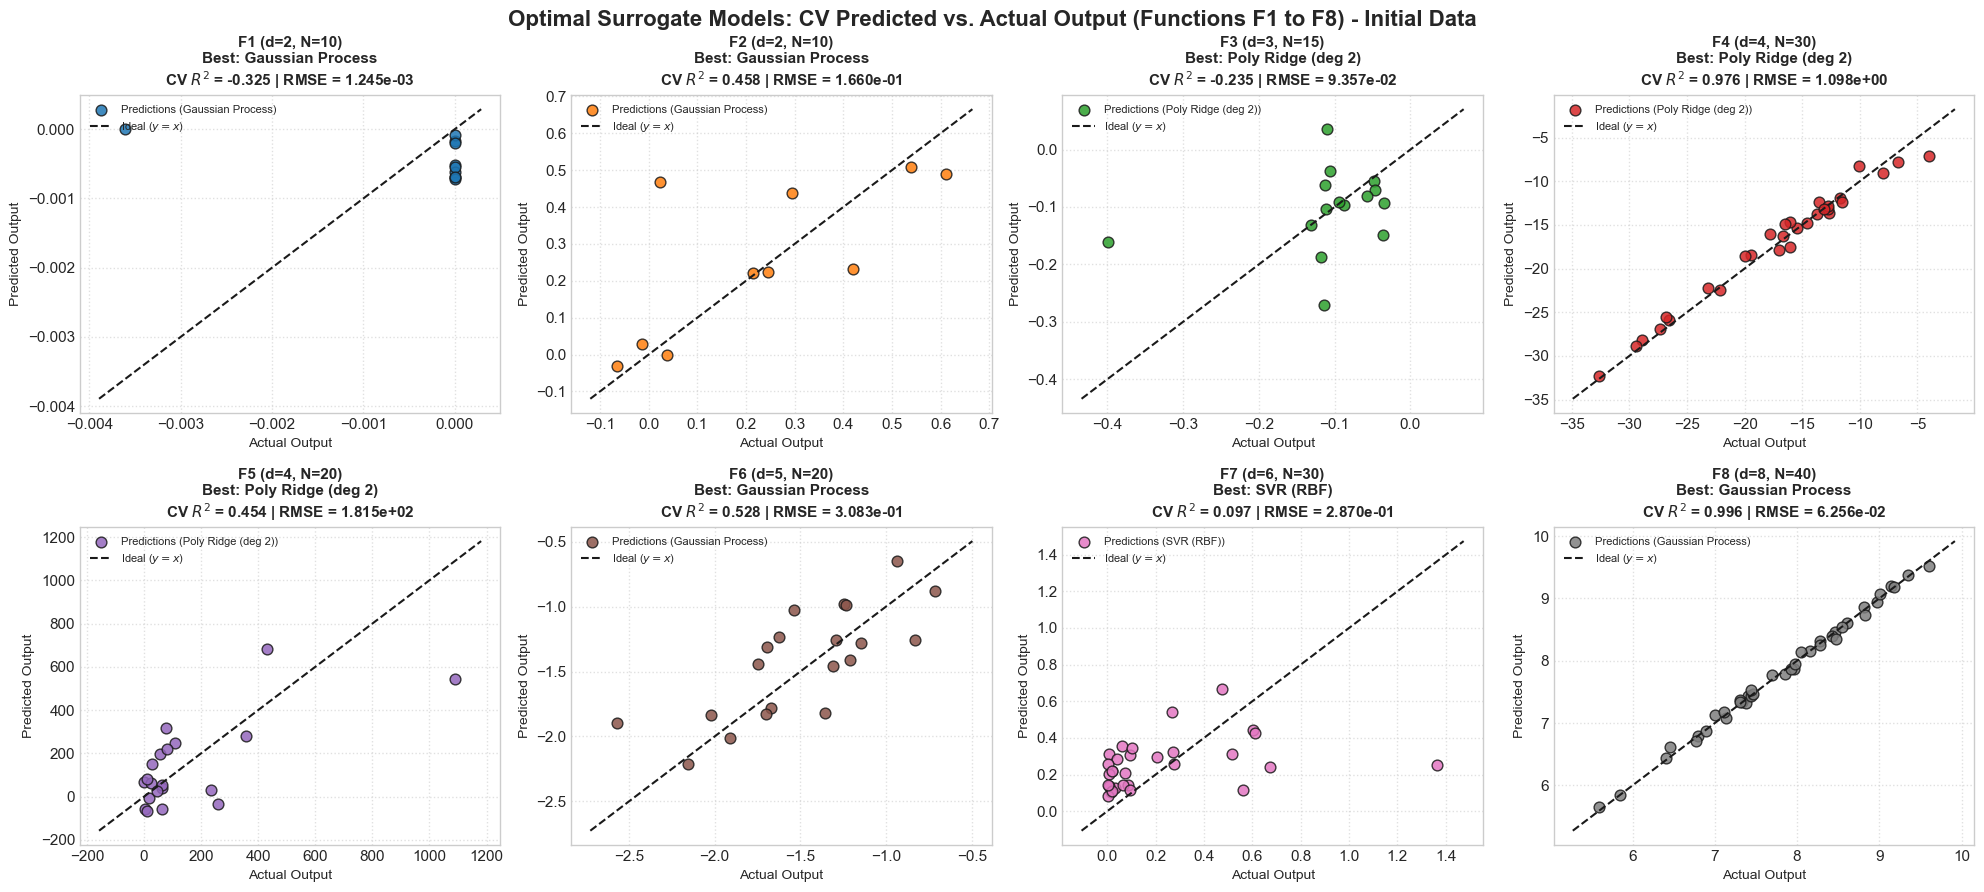

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Colors for each function
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for idx, s in enumerate(sheets):
    info = best_models[s]
    y_act = info['y_actual']
    y_pr = info['y_pred']
    model_name = info['best_model_name']
    r2_val = info['best_r2']
    rmse_val = np.sqrt(mean_squared_error(y_act, y_pr))
    
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(y_act, y_pr, color=colors[idx], edgecolors='k', alpha=0.85, s=60, label=f'Predictions ({model_name})')
    
    # y = x line
    min_v = min(min(y_act), min(y_pr))
    max_v = max(max(y_act), max(y_pr))
    margin = (max_v - min_v) * 0.08 if max_v != min_v else 0.1
    line_x = np.linspace(min_v - margin, max_v + margin, 100)
    ax.plot(line_x, line_x, 'k--', linewidth=1.5, label='Ideal ($y = x$)')
    
    ax.set_title(f"{s} (d={info['d']}, N={info['N']})\nBest: {model_name}\nCV $R^2$ = {r2_val:.3f} | RMSE = {rmse_val:.3e}", 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Output', fontsize=10)
    ax.set_ylabel('Predicted Output', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Optimal Surrogate Models: CV Predicted vs. Actual Output (Functions F1 to F8) - Initial Data', fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
# plt.savefig('optimal_surrogate_models_all_functions.png', dpi=300)
# plt.close()

# print("Plot saved as optimal_surrogate_models_all_functions.png")

# 1. Load libraries and import data

In [8]:
import numpy as np # for working with arrays
import pandas as pd # for data manipulation and analysis

import seaborn as sns # to visualise attractive, informative statistical graphics
import matplotlib.pyplot as plt # to create static, animated, and interactive visualisations 

import statsmodels.api as sm  # to estimate statistical models, conduct statistical tests, and perform data exploration


In [9]:
# Read the data
# To ease the process, all NumPy inputs and outputs are prepared in the Excel file.

df1 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F1")
df2 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F2")
df3 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F3")
df4 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F4")
df5 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F5")
df6 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F6")
df7 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F7")
df8 = pd.read_excel(open("initial_data/CapstoneFunction_from_Numpy.xlsx", "rb"), sheet_name="F8")

In [10]:
# Check the data type example, Function 1
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Input_1  10 non-null     float64
 1   Input_2  10 non-null     float64
 2   Output   10 non-null     float64
dtypes: float64(3)
memory usage: 372.0 bytes


In [11]:
# Check an example of a dataframe, Function 8

df8.head(3)

,Input_1,Input_2,Input_3,Input_4,Input_5,Input_6,Input_7,Input_8,Output
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482


Function 1: Radiation field (2D array, 10 samples)

Function 2:  Unspecified field (2D array, 10 samples)

Function 3:  A drug discovery project (3D array, 15 samples)

Function 4:  Warehouse business (4D array, 30 samples)

Function 5:  A chemical process in a factory (4D array, 20 samples)

Function 6:  A cake recipe (5D array, 20 samples)

Function 7:  Unspecified field (6D array, 30 samples)

Function 8:  Unspecified field (8D array, 40 samples)

# 2. Understanding correlation between inputs and outputs

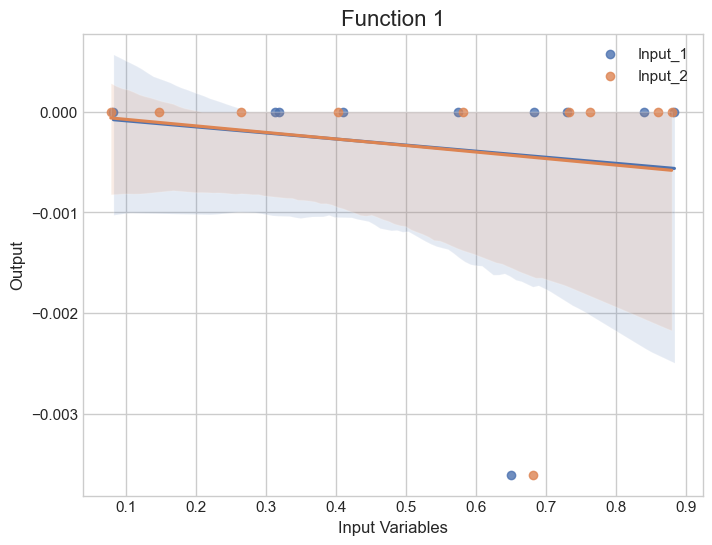

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
# Plot one regression
sns.regplot(data=df1, x="Input_1", y="Output", ax=ax, label='Input_1')

# Plot a second regression on the same axes
sns.regplot(data=df1, x="Input_2", y="Output", ax=ax, label='Input_2')

plt.xlabel("Input Variables")
plt.title("Function 1", fontsize=16)
ax.legend()
plt.show()

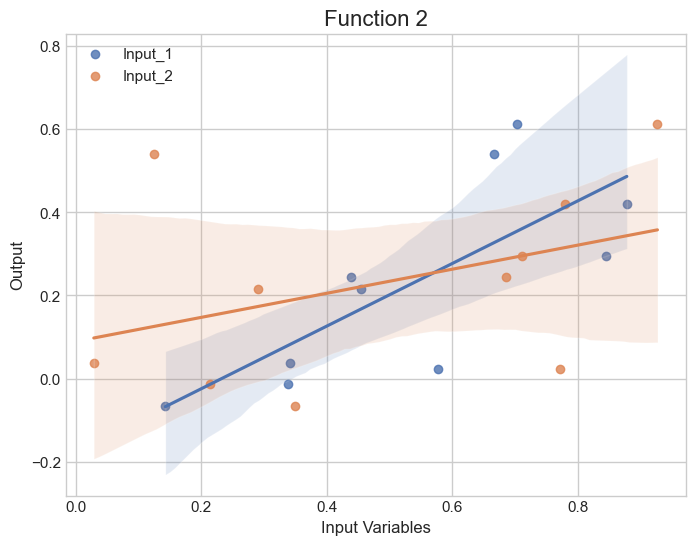

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df2, x="Input_1", y="Output", ax=ax, label='Input_1')
sns.regplot(data=df2, x="Input_2", y="Output", ax=ax, label='Input_2')

plt.xlabel("Input Variables")
plt.title("Function 2", fontsize=16)
ax.legend()
plt.show()

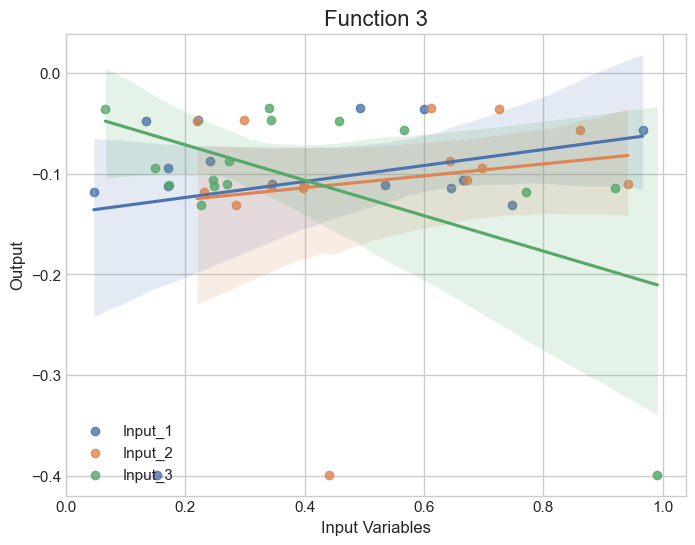

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df3, x="Input_1", y="Output", ax=ax, label='Input_1')
sns.regplot(data=df3, x="Input_2", y="Output", ax=ax, label='Input_2')
sns.regplot(data=df3, x="Input_3", y="Output", ax=ax, label='Input_3')


plt.xlabel("Input Variables")
plt.title("Function 3", fontsize=16)
ax.legend()
plt.show()

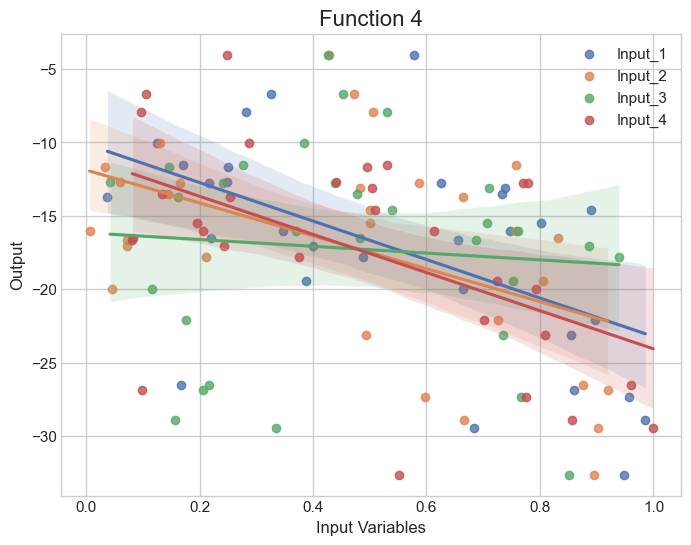

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df4, x="Input_1", y="Output", ax=ax, label='Input_1')
sns.regplot(data=df4, x="Input_2", y="Output", ax=ax, label='Input_2')
sns.regplot(data=df4, x="Input_3", y="Output", ax=ax, label='Input_3')
sns.regplot(data=df4, x="Input_4", y="Output", ax=ax, label='Input_4')

plt.xlabel("Input Variables")
plt.title("Function 4", fontsize=16)
ax.legend()
plt.show()

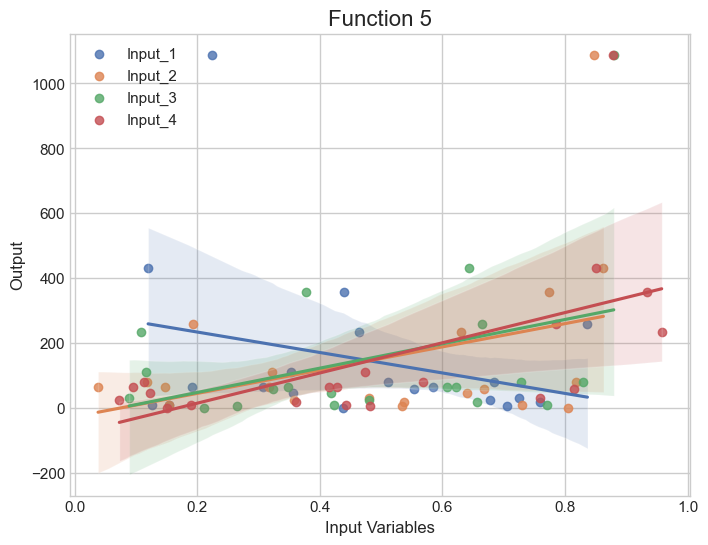

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df5, x="Input_1", y="Output", ax=ax, label='Input_1')
sns.regplot(data=df5, x="Input_2", y="Output", ax=ax, label='Input_2')
sns.regplot(data=df5, x="Input_3", y="Output", ax=ax, label='Input_3')
sns.regplot(data=df5, x="Input_4", y="Output", ax=ax, label='Input_4')

plt.xlabel("Input Variables")
plt.title("Function 5", fontsize=16)
ax.legend()
plt.show()

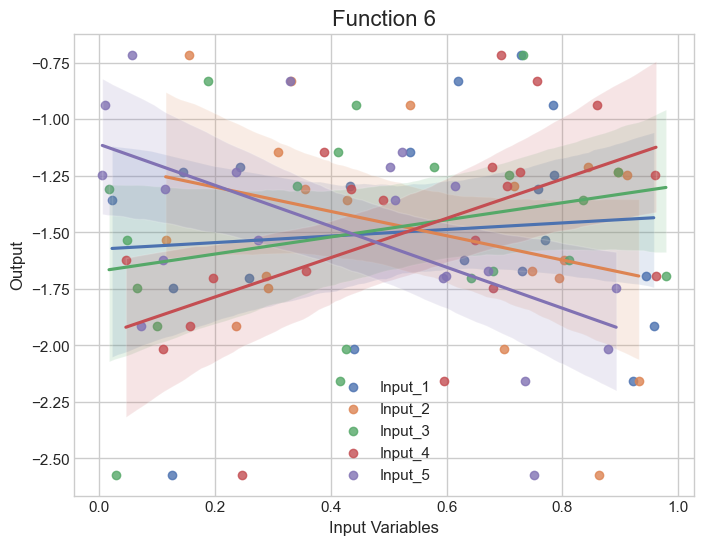

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df6, x="Input_1", y="Output", ax=ax, label='Input_1')
sns.regplot(data=df6, x="Input_2", y="Output", ax=ax, label='Input_2')
sns.regplot(data=df6, x="Input_3", y="Output", ax=ax, label='Input_3')
sns.regplot(data=df6, x="Input_4", y="Output", ax=ax, label='Input_4')
sns.regplot(data=df6, x="Input_5", y="Output", ax=ax, label='Input_5')

plt.xlabel("Input Variables")
plt.title("Function 6", fontsize=16)
ax.legend()
plt.show()

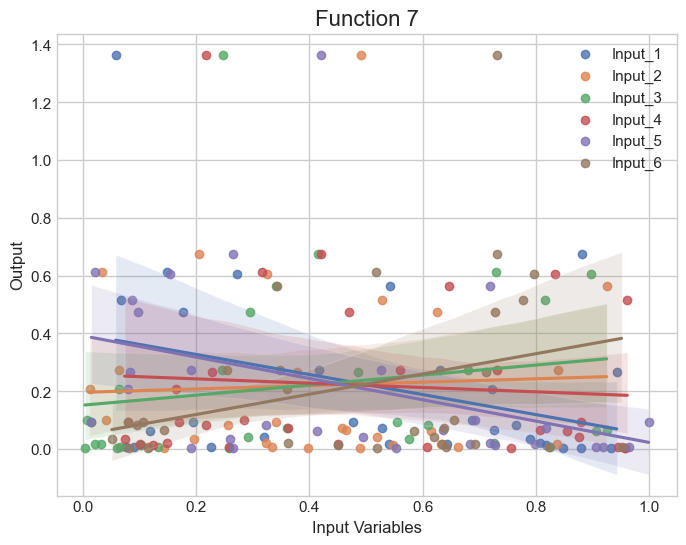

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df7, x="Input_1", y="Output", ax=ax, label='Input_1')
sns.regplot(data=df7, x="Input_2", y="Output", ax=ax, label='Input_2')
sns.regplot(data=df7, x="Input_3", y="Output", ax=ax, label='Input_3')
sns.regplot(data=df7, x="Input_4", y="Output", ax=ax, label='Input_4')
sns.regplot(data=df7, x="Input_5", y="Output", ax=ax, label='Input_5')
sns.regplot(data=df7, x="Input_6", y="Output", ax=ax, label='Input_6')

plt.xlabel("Input Variables")
plt.title("Function 7", fontsize=16)
ax.legend()
plt.show()

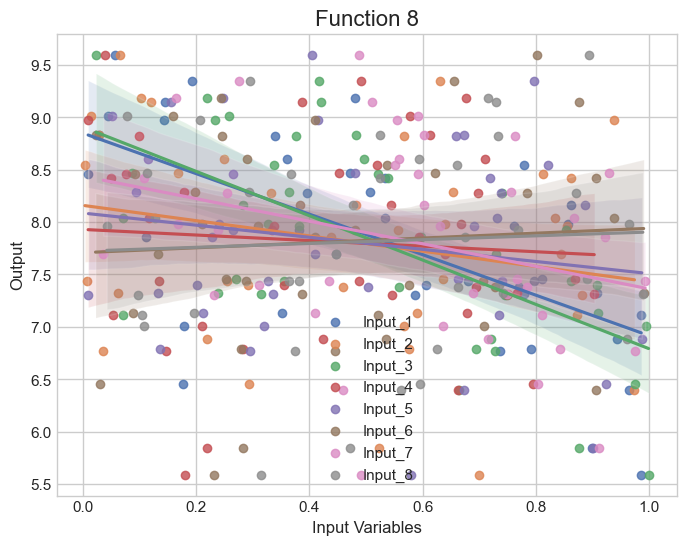

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df8, x="Input_1", y="Output", ax=ax, label='Input_1')
sns.regplot(data=df8, x="Input_2", y="Output", ax=ax, label='Input_2')
sns.regplot(data=df8, x="Input_3", y="Output", ax=ax, label='Input_3')
sns.regplot(data=df8, x="Input_4", y="Output", ax=ax, label='Input_4')
sns.regplot(data=df8, x="Input_5", y="Output", ax=ax, label='Input_5')
sns.regplot(data=df8, x="Input_6", y="Output", ax=ax, label='Input_6')
sns.regplot(data=df8, x="Input_7", y="Output", ax=ax, label='Input_7')
sns.regplot(data=df8, x="Input_8", y="Output", ax=ax, label='Input_8')

plt.xlabel("Input Variables")
plt.title("Function 8", fontsize=16)
ax.legend()
plt.show()

In [20]:
import pandas as pd

# Classify functions based on observed linear correlation and feature importance results
classification = {
    1: {'Observation': 'Extreme outliers', 'Linear_trends': 'Negative'},
    2: {'Observation': 'No Correlation', 'Linear_trends': 'Positive'},
    3: {'Observation': 'Extreme outliers', 'Linear_trends': 'Both Negative and Positive'},
    4: {'Observation': 'No Correlation', 'Linear_trends': 'Negative'},
    5: {'Observation': 'Extreme outliers', 'Linear_trends': 'Both Negative and Positive'},
    6: {'Observation': 'No Correlation', 'Linear_trends': 'Both Negative and Positive'},
    7: {'Observation': 'Extreme outliers', 'Linear_trends': 'Both Negative and Positive'},
    8: {'Observation': 'No Correlation', 'Linear_trends': 'Negative'}
}

class_df = pd.DataFrame([
    {'Function': fid, **info} for fid, info in classification.items()
])

print("Function Classification:")
print(class_df.to_string(index=False))

Function Classification:
 Function      Observation              Linear_trends
        1 Extreme outliers                   Negative
        2   No Correlation                   Positive
        3 Extreme outliers Both Negative and Positive
        4   No Correlation                   Negative
        5 Extreme outliers Both Negative and Positive
        6   No Correlation Both Negative and Positive
        7 Extreme outliers Both Negative and Positive
        8   No Correlation                   Negative


# Correlation Matrix with Heatmap

A heatmap correlation matrix is a visual representation of relationships between multiple variables in a dataset. 

It displays correlation coefficients in a colour-coded grid, allowing you to instantly identify which variables are strongly positively correlated, negatively correlated, or have no relationship at all.

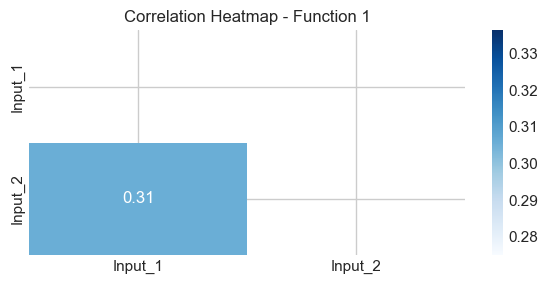

In [21]:
fig = plt.figure(figsize=(6,3))

corr1 = df1.drop(["Output"], axis=1).corr()
mask1 = np.triu(np.ones_like(corr1, dtype=bool))
fig = sns.heatmap(corr1, mask=mask1, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 1', size=12)
plt.tight_layout()

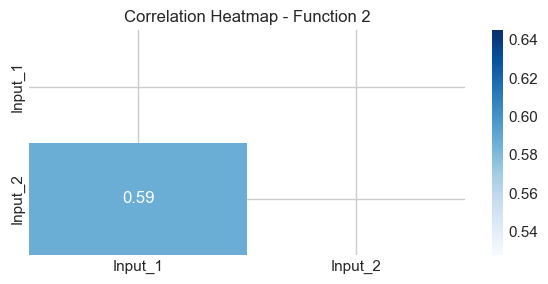

In [22]:
fig = plt.figure(figsize=(6,3))

corr2 = df2.drop(["Output"], axis=1).corr()
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
fig = sns.heatmap(corr2, mask=mask2, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 2', size=12)
plt.tight_layout()

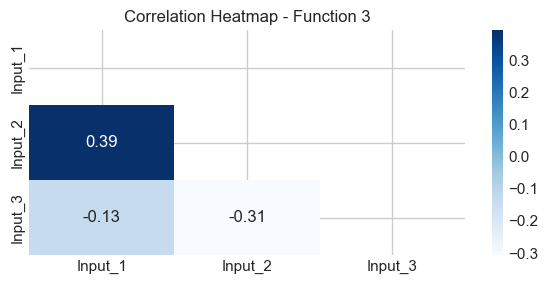

In [23]:
fig = plt.figure(figsize=(6,3))

corr3 = df3.drop(["Output"], axis=1).corr()
mask3 = np.triu(np.ones_like(corr3, dtype=bool))
fig = sns.heatmap(corr3, mask=mask3, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 3', size=12)
plt.tight_layout()

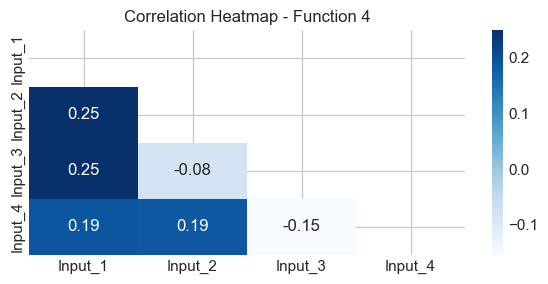

In [24]:
fig = plt.figure(figsize=(6,3))

corr4 = df4.drop(["Output"], axis=1).corr()
mask4 = np.triu(np.ones_like(corr4, dtype=bool))
fig = sns.heatmap(corr4, mask=mask4, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 4', size=12)
plt.tight_layout()

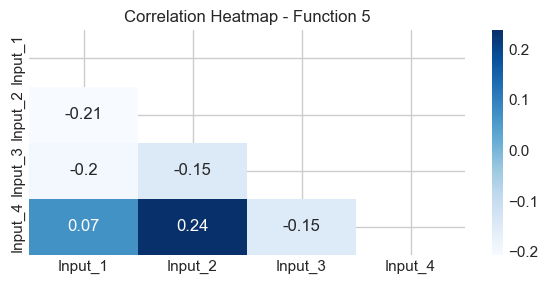

In [25]:
fig = plt.figure(figsize=(6,3))

corr5 = df5.drop(["Output"], axis=1).corr()
mask5 = np.triu(np.ones_like(corr5, dtype=bool))
fig = sns.heatmap(corr5, mask=mask5, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 5', size=12)
plt.tight_layout()

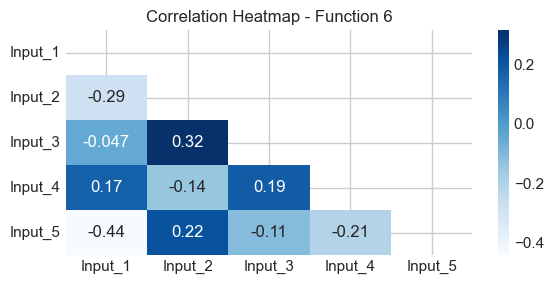

In [26]:
fig = plt.figure(figsize=(6,3))

corr6 = df6.drop(["Output"], axis=1).corr()
mask6 = np.triu(np.ones_like(corr6, dtype=bool))
fig = sns.heatmap(corr6, mask=mask6, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 6', size=12)
plt.tight_layout()

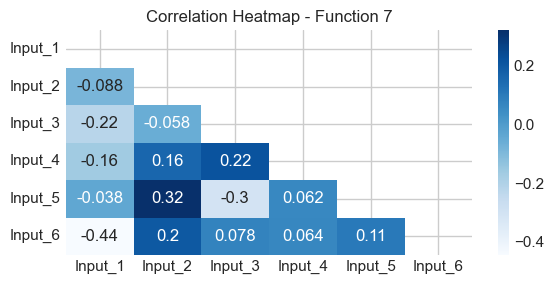

In [27]:
fig = plt.figure(figsize=(6,3))

corr7 = df7.drop(["Output"], axis=1).corr()
mask7 = np.triu(np.ones_like(corr7, dtype=bool))
fig = sns.heatmap(corr7, mask=mask7, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 7', size=12)
plt.tight_layout()

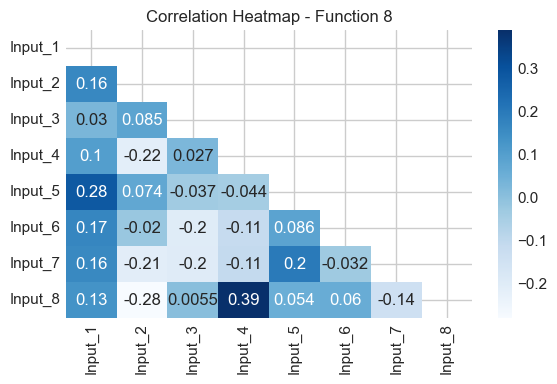

In [28]:
fig = plt.figure(figsize=(6,4))

corr8 = df8.drop(["Output"], axis=1).corr()
mask8 = np.triu(np.ones_like(corr8, dtype=bool))
fig = sns.heatmap(corr8, mask=mask8, annot=True, cmap='Blues')
fig.set_title('Correlation Heatmap - Function 8', size=12)
plt.tight_layout()

# 4. Histogram and Box Plots

A histogram instantly reveals the shape and spread of the data (like peaks and skewness).

A box plot identifies exact statistics like median, mean and outliers.

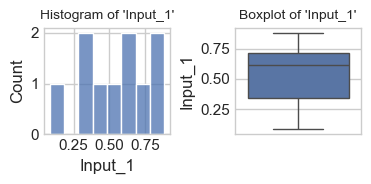

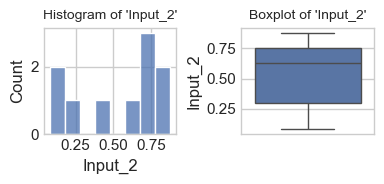

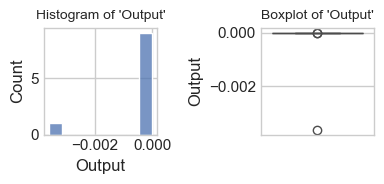

In [29]:
num_cols = [col for col in df1.columns if df1[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df1[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df1[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

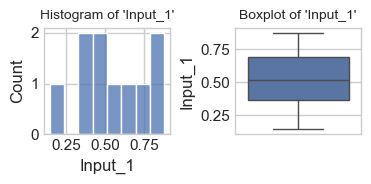

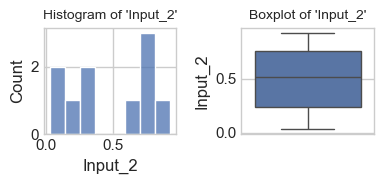

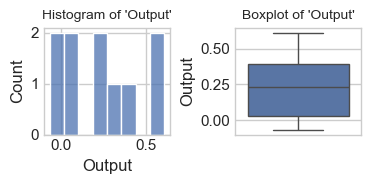

In [30]:
num_cols = [col for col in df2.columns if df2[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df2[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df2[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

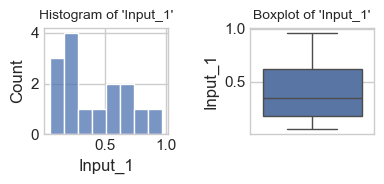

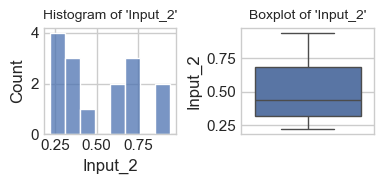

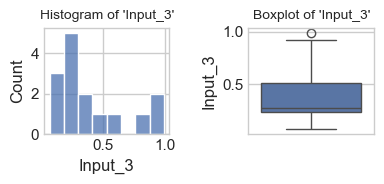

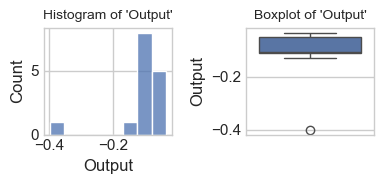

In [31]:
num_cols = [col for col in df3.columns if df3[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df3[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df3[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

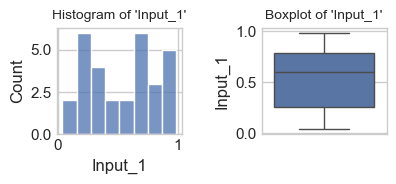

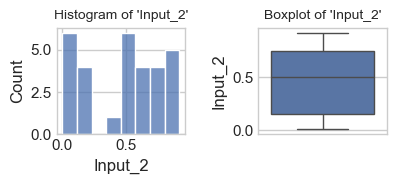

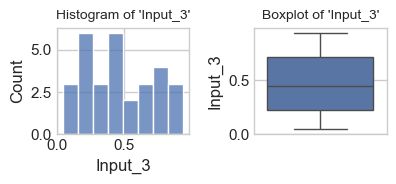

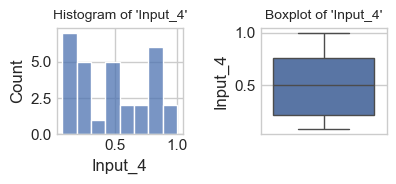

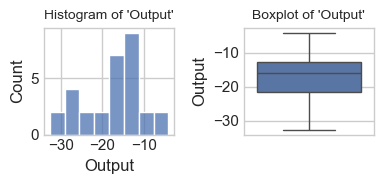

In [32]:
num_cols = [col for col in df4.columns if df4[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df4[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df4[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

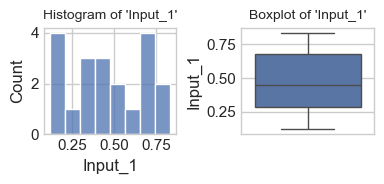

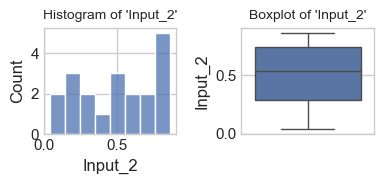

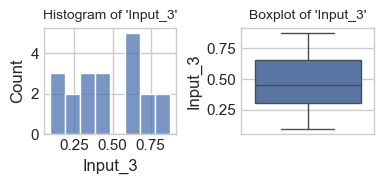

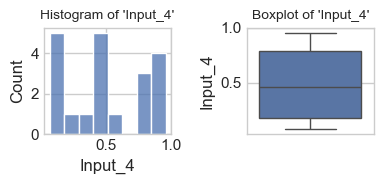

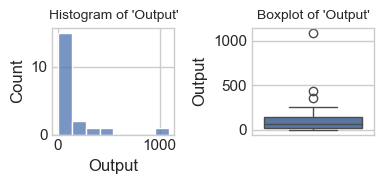

In [33]:
num_cols = [col for col in df5.columns if df5[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df5[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df5[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

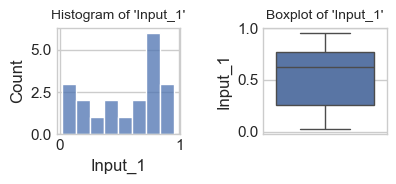

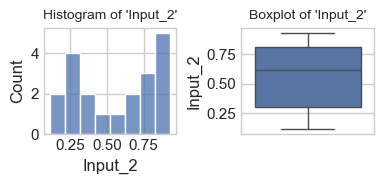

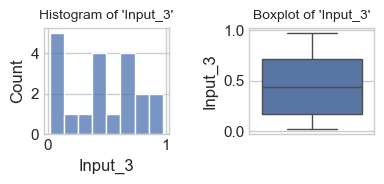

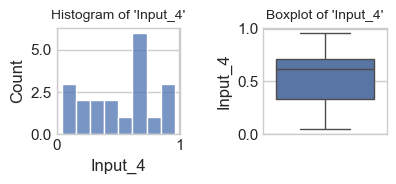

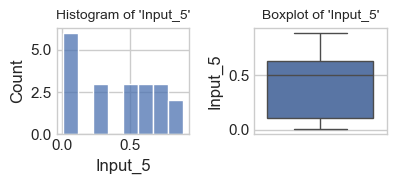

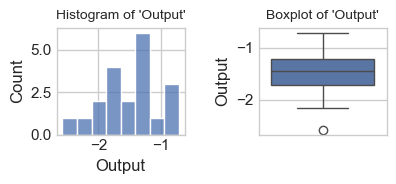

In [34]:
num_cols = [col for col in df6.columns if df6[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df6[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df6[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

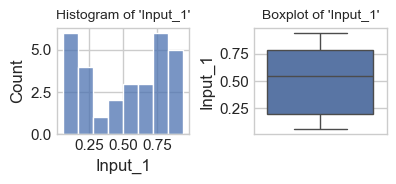

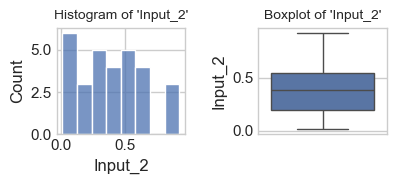

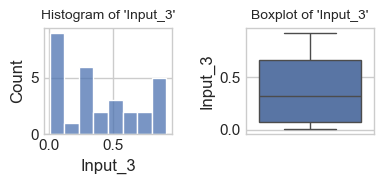

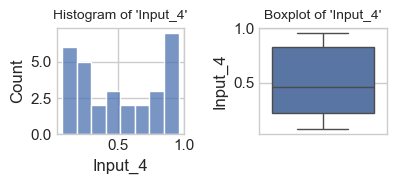

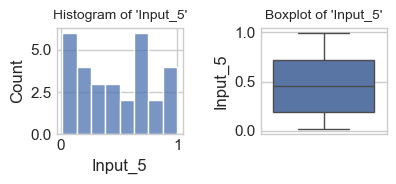

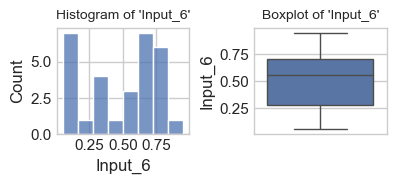

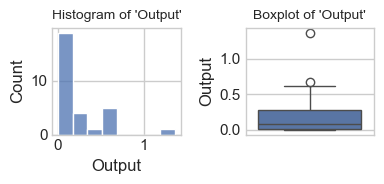

In [35]:
num_cols = [col for col in df7.columns if df7[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df7[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df7[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

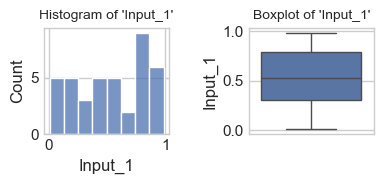

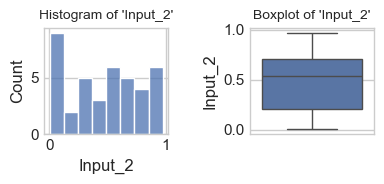

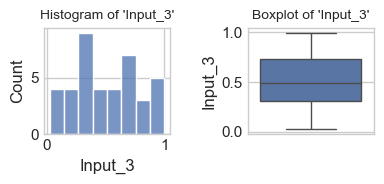

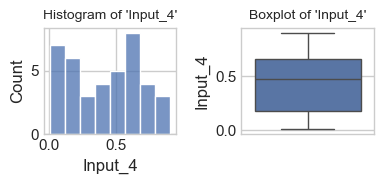

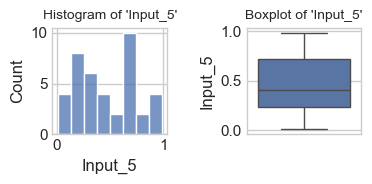

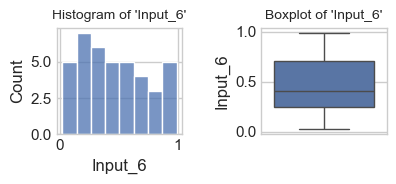

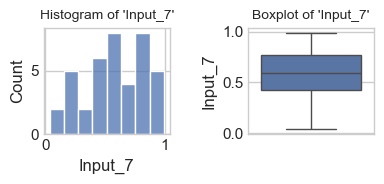

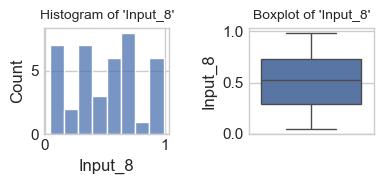

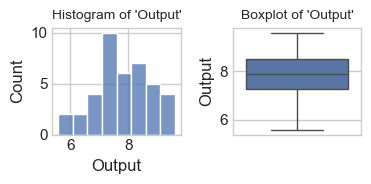

In [36]:
num_cols = [col for col in df8.columns if df8[col].dtypes != 'O']


for col in num_cols:

    fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(4,2))

    ax1 = sns.histplot(df8[col], bins=8, ax=ax1)
    ax1.set_title(f"Histogram of '{col}'", size=10)

    ax2 = sns.boxplot(df8[col], ax=ax2)
    ax2.set_title(f"Boxplot of '{col}'", size=10)
    
    plt.tight_layout()

# 5. Pair Plots

A pair plot, also known as a scatterplot matrix, provides a comprehensive view of the interplay between multiple variables in a dataset. 

Unlike correlation heatmaps, which represent correlation coefficients in a colour-coded grid, pair plots depict the actual data points, revealing the nature of relationships beyond just their strength and direction.

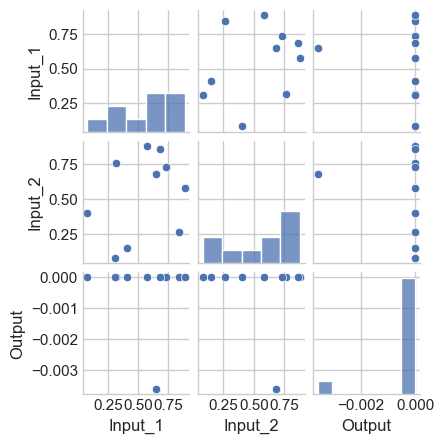

In [37]:
g = sns.pairplot(df1, diag_kind="hist", height=1.5)

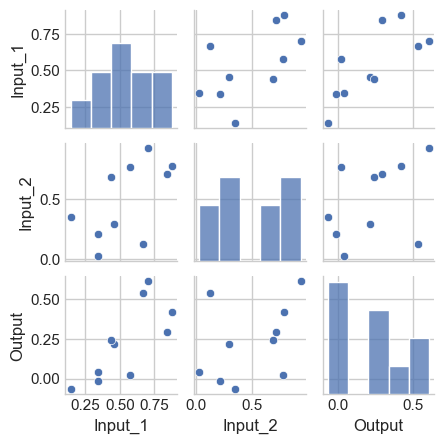

In [38]:
g = sns.pairplot(df2, diag_kind="hist", height=1.5)

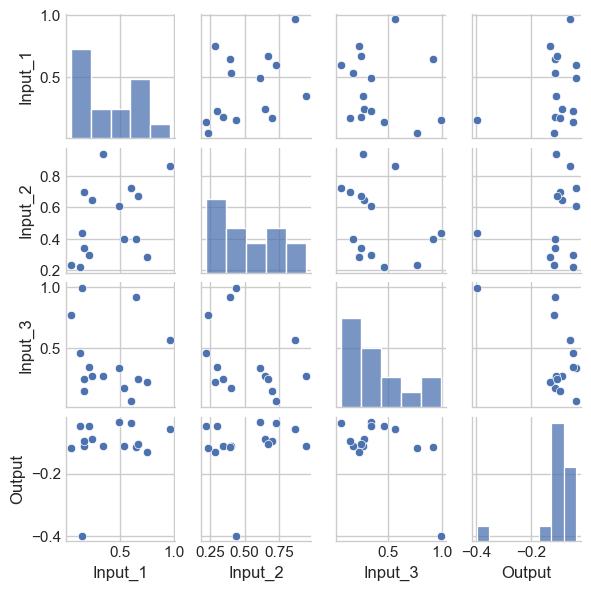

In [39]:
g = sns.pairplot(df3, diag_kind="hist", height=1.5)

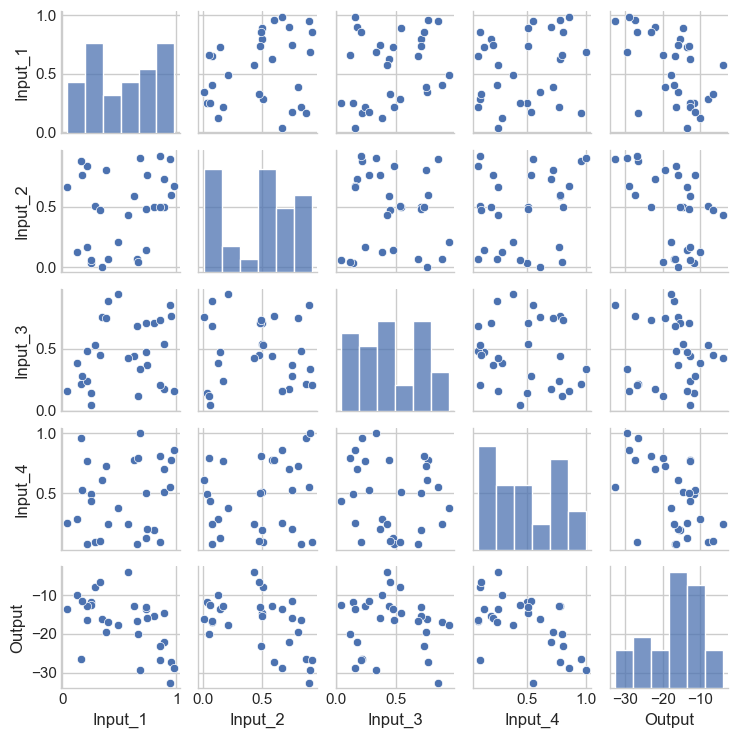

In [40]:
g = sns.pairplot(df4, diag_kind="hist", height=1.5)

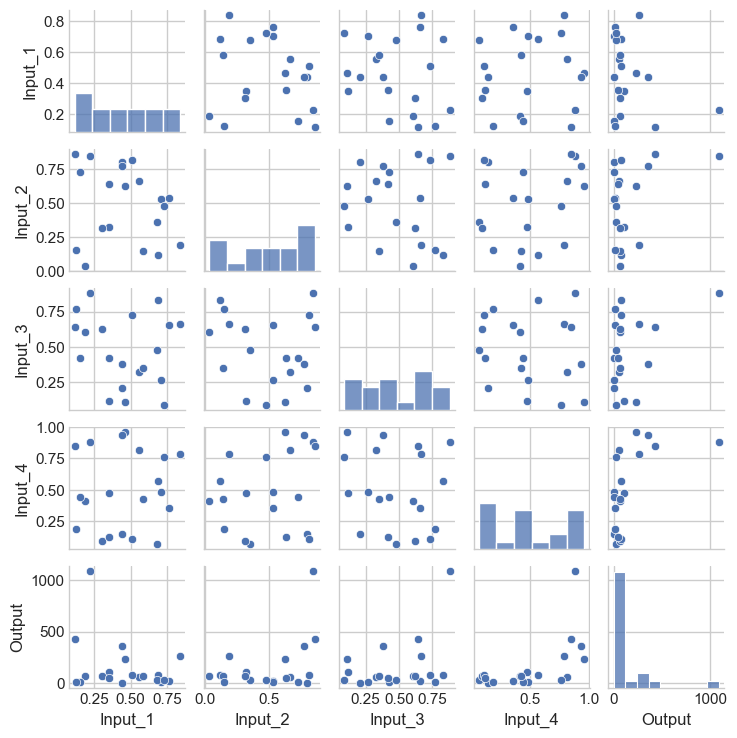

In [41]:
g = sns.pairplot(df5, diag_kind="hist", height=1.5)

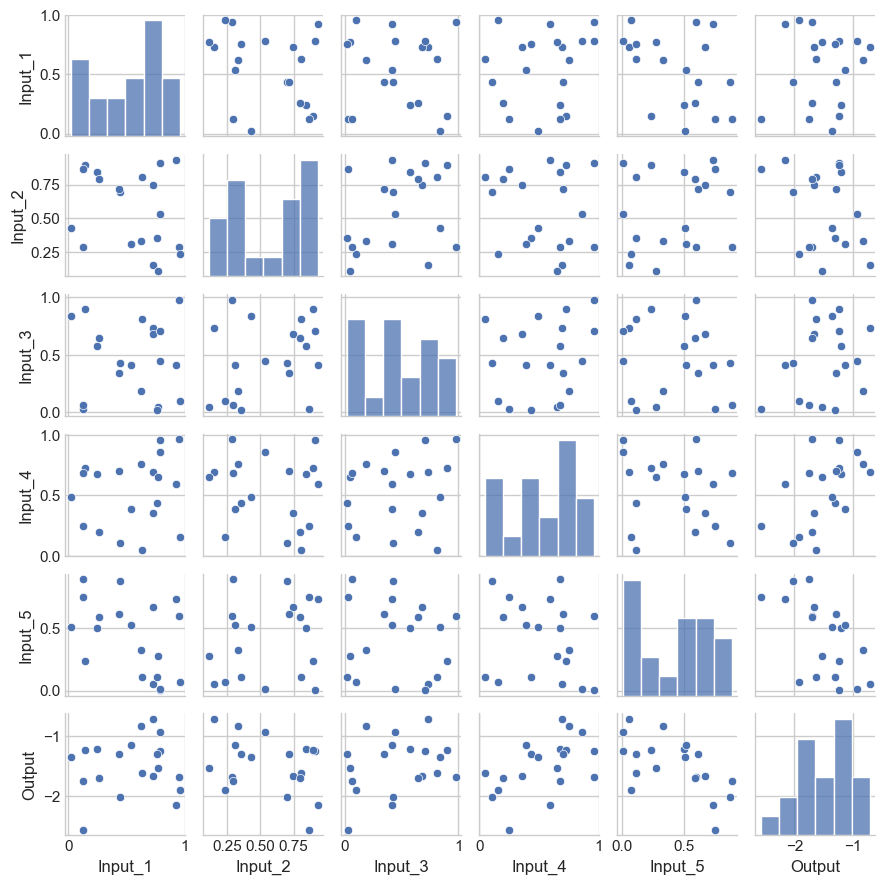

In [42]:
g = sns.pairplot(df6, diag_kind="hist", height=1.5)

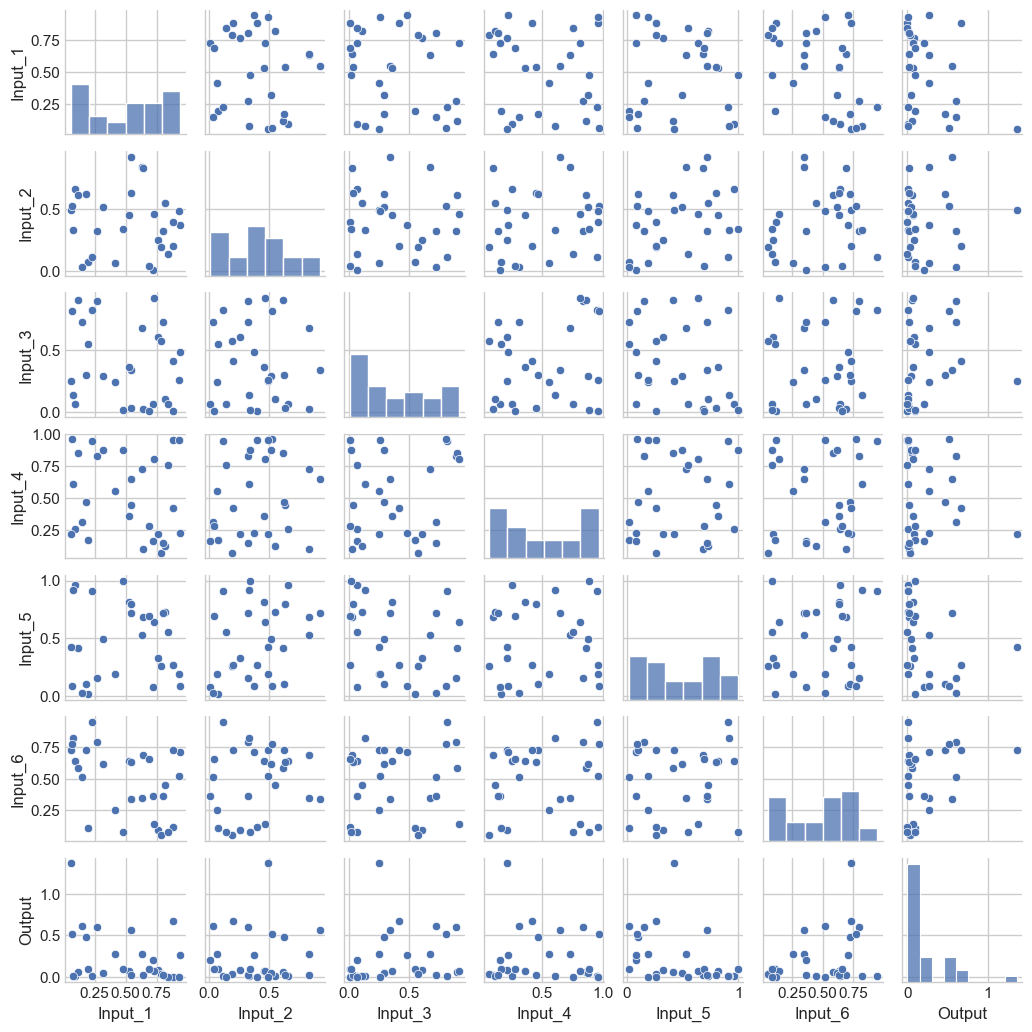

In [43]:
g = sns.pairplot(df7, diag_kind="hist", height=1.5)

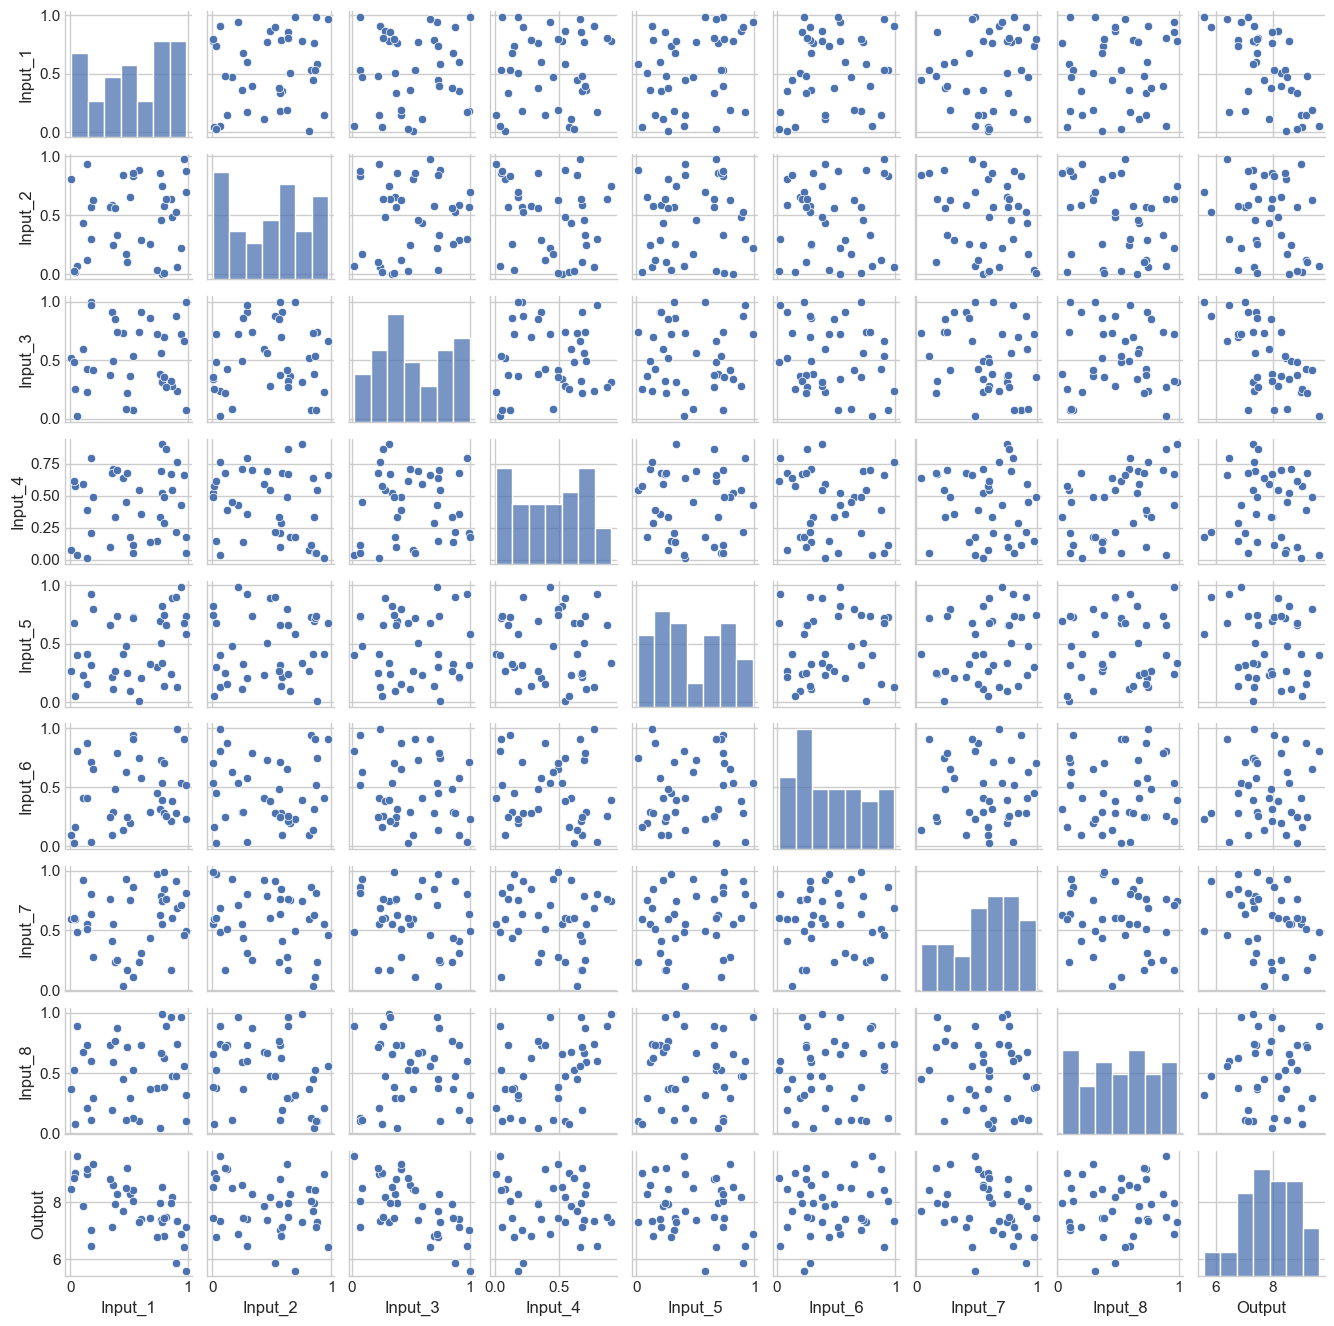

In [44]:
g = sns.pairplot(df8, diag_kind="hist", height=1.5)